# Stage 10b: Time Series & Classification
Fill in the TODOs. Use your own project dataset or adapt the synthetic generator below.

In [ ]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [1]:
# Imports
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, TimeSeriesSplit
np.random.seed(7); sns.set(); plt.rcParams['figure.figsize']=(9,4)

## Option B: Synthetic Generator (Use if you don't have data ready)

In [2]:
# Synthetic series with regimes & jumps
n=500
dates=pd.bdate_range('2021-01-01', periods=n)
mu = np.where(np.arange(n)<n//2, 0.0003, -0.0001)
sigma = np.where(np.arange(n)<n//2, 0.01, 0.015)
eps = np.random.normal(mu, sigma)
jumps = np.zeros(n); jump_days = np.random.choice(np.arange(20,n-20), size=5, replace=False)
jumps[jump_days] = np.random.normal(0,0.05,size=len(jump_days))
rets = eps + jumps
price = 100*np.exp(np.cumsum(rets))
df = pd.DataFrame({'price':price}, index=dates)
df['ret'] = df['price'].pct_change().fillna(0.0)
df['log_ret'] = np.log1p(df['ret'])
df.head()

,price,ret,log_ret
2021-01-01,101.735412,0.000000,0.000000
2021-01-04,101.292875,-0.004350,-0.004359
2021-01-05,101.356527,0.000628,0.000628
2021-01-06,101.800950,0.004385,0.004375
2021-01-07,101.031283,-0.007561,-0.007589


## Feature Engineering

In [3]:
# TODO: create at least two features
df['lag_1'] = df['ret'].shift(1)
df['roll_mean_5'] = df['ret'].rolling(5).mean().shift(1)
# Add your own:
# df['roll_vol_20'] = df['ret'].rolling(20).std().shift(1)
df['y_next_ret'] = df['ret'].shift(-1)
df['y_up'] = (df['y_next_ret']>0).astype(int)
df_feat = df.dropna().copy()
df_feat.head()

,price,ret,log_ret,lag_1,roll_mean_5,y_next_ret,y_up
2021-01-08,101.063685,0.000321,0.000321,-0.007561,-0.001379,0.000291,1
2021-01-11,101.093108,0.000291,0.000291,0.000321,-0.001315,-0.017099,0
2021-01-12,99.364481,-0.017099,-0.017247,0.000291,-0.000387,0.010532,1
2021-01-13,100.410953,0.010532,0.010477,-0.017099,-0.003933,0.006325,1
2021-01-14,101.046042,0.006325,0.006305,0.010532,-0.002703,-0.005937,0


## Split

In [4]:
# Time-aware split
cut=int(len(df_feat)*0.8)
train, test = df_feat.iloc[:cut], df_feat.iloc[cut:]
features=['lag_1','roll_mean_5']  # extend as you add features
X_tr, X_te = train[features], test[features]
y_tr_reg, y_te_reg = train['y_next_ret'], test['y_next_ret']
y_tr_clf, y_te_clf = train['y_up'], test['y_up']

## Pipeline + Model (Choose one track below)

In [5]:
# Track 1: Forecasting returns
reg = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])
reg.fit(X_tr, y_tr_reg)
pred = reg.predict(X_te)
rmse = mean_squared_error(y_te_reg, pred) ** 0.5   # `squared=False` was removed in sklearn >= 1.6
print('RMSE:', rmse)

RMSE: 0.014524324812974158


              precision    recall  f1-score   support

           0       0.55      0.72      0.62        54
           1       0.46      0.29      0.36        45

    accuracy                           0.53        99
   macro avg       0.51      0.51      0.49        99
weighted avg       0.51      0.53      0.50        99



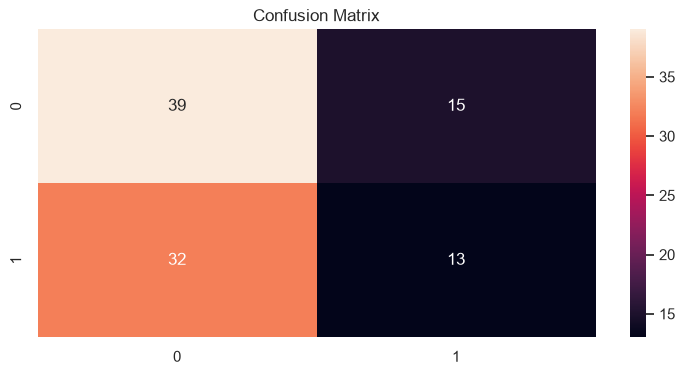

In [6]:
# Track 2: Classification (up/down)
clf = Pipeline([('scaler', StandardScaler()), ('logit', LogisticRegression(max_iter=1000))])
clf.fit(X_tr, y_tr_clf)
predc = clf.predict(X_te)
print(classification_report(y_te_clf, predc))
cm = confusion_matrix(y_te_clf, predc)
sns.heatmap(cm, annot=True, fmt='d'); plt.title('Confusion Matrix'); plt.show()

## Interpretation

- **What worked?**  
  The time-aware train/test split avoids using future observations to predict the past. 
  The lagged return and rolling mean provide simple historical information for predicting the next-period return or direction.

- **Where might assumptions fail?**  
  Linear and logistic regression assume relatively simple relationships between the features and the target. 
  Financial returns may have nonlinear patterns, regime changes, jumps, and changing volatility, so these assumptions may not always hold.

- **How would you extend features or model?**  
  I would add more lagged returns and rolling features, such as 5-day and 20-day volatility. 
  I could also try nonlinear models such as decision trees or other machine-learning models and compare their out-of-sample performance.

### Save Notebook
Remember to save as `homework10b_modeling-time-series-and-classification_submission.ipynb`.